## 0. Colab Setup

In [1]:
# Check GPU availability
import torch
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

GPU Available: True
GPU: NVIDIA L4
Memory: 23.80 GB


In [2]:
# Mount Google Drive (optional - skip if uploading files directly)
from google.colab import drive
drive.mount('/content/drive')

# Set your data directory path in Google Drive
# Adjust this path to match your Drive structure
DRIVE_BASE = '/content/drive/MyDrive/drugresponse'

Mounted at /content/drive


In [3]:
# Install required packages
!pip install -q torch torchvision torchaudio
!pip install -q pyarrow  # For reading parquet files

print("✓ Packages installed")

✓ Packages installed


In [4]:
# Define utility classes (copied from src/utils.py)
import random
import numpy as np
import torch

def set_seed(seed=42):
    """Set random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class EarlyStopping:
    """Early stopping to prevent overfitting"""
    def __init__(self, patience=10, mode='min', delta=0):
        self.patience = patience
        self.mode = mode
        self.delta = delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
        elif self.mode == 'min':
            if score > self.best_score - self.delta:
                self.counter += 1
                if self.counter >= self.patience:
                    self.early_stop = True
            else:
                self.best_score = score
                self.counter = 0
        else:  # mode == 'max'
            if score < self.best_score + self.delta:
                self.counter += 1
                if self.counter >= self.patience:
                    self.early_stop = True
            else:
                self.best_score = score
                self.counter = 0
        return self.early_stop

print("✓ Utility classes defined")

✓ Utility classes defined


## 1. Setup and Baseline Performance

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from pathlib import Path
from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Paths - adjust based on your setup
USE_DRIVE = True  # Set to False if uploading files directly

if USE_DRIVE:
    DATA_DIR = Path(DRIVE_BASE) / 'data' / 'processed'
    RESULTS_DIR = Path(DRIVE_BASE) / 'results'
else:
    DATA_DIR = Path('/content/data/processed')
    RESULTS_DIR = Path('/content/results')

ABLATION_DIR = RESULTS_DIR / 'ablation_studies'
ABLATION_DIR.mkdir(parents=True, exist_ok=True)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

set_seed(42)
print("✓ Setup complete")

Device: cuda
✓ Setup complete


In [ ]:
# Load baseline performance from existing models
baseline_metrics = {
    'MLP Baseline': pd.read_csv(RESULTS_DIR / 'mlp_baseline_with_splits/metrics_val_test.csv'),
    'MLP + ChemBERTa': pd.read_csv(RESULTS_DIR / 'mlp_chemberta/metrics_val_test.csv'),
    'MLP + ChemBERTa (Tuned)': pd.read_csv(RESULTS_DIR / 'mlp_chemberta_tuned/final_test_metrics.csv'),
    'ChemBERTa Finetuned': pd.read_csv(RESULTS_DIR / 'chemberta_finetune/metrics_val_test.csv'),
}

print("="*70)
print("BASELINE PERFORMANCE (Full Models)")
print("="*70)
for model_name, metrics_df in baseline_metrics.items():
    if 'test_spearman' in metrics_df.columns:
        spearman = metrics_df['test_spearman'].iloc[0]
        rmse = metrics_df['test_rmse'].iloc[0]
    elif 'spearman' in metrics_df.columns:
        test_row = metrics_df[metrics_df['split'] == 'test'].iloc[0]
        spearman = test_row['spearman']
        rmse = test_row['rmse']
    else:
        continue
    print(f"{model_name:30s}: Spearman={spearman:.4f}, RMSE={rmse:.4f}")
print("="*70)

BASELINE PERFORMANCE (Full Models)
MLP Baseline                  : Spearman=0.3559, RMSE=2.6935
MLP + ChemBERTa               : Spearman=0.4069, RMSE=2.5876
MLP + ChemBERTa (Tuned)       : Spearman=0.4498, RMSE=2.3920


## 2. Load Data for Ablation Experiments

In [7]:
# Load full dataset (use parquet - matches training data and splits)
df = pd.read_parquet(DATA_DIR / 'merged.parquet')
expr_pca = pd.read_csv(DATA_DIR / 'gdsc_expr_pca.csv')
chemberta_feats = np.load(DATA_DIR / 'chemberta_drug_feats.npz')

# Load splits
train_idx = np.load(DATA_DIR / 'splits_drug/train_idx.npy')
val_idx = np.load(DATA_DIR / 'splits_drug/val_idx.npy')
test_idx = np.load(DATA_DIR / 'splits_drug/test_idx.npy')

df_train = df.iloc[train_idx].reset_index(drop=True)
df_val = df.iloc[val_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

print(f"Dataset: {len(df):,} samples")
print(f"Train: {len(train_idx):,}, Val: {len(val_idx):,}, Test: {len(test_idx):,}")
print(f"Expression PCs: {expr_pca.shape[1]-1}")
print(f"ChemBERTa dims: {chemberta_feats['feats'].shape[1]}")

Dataset: 562,789 samples
Train: 395,596, Val: 54,216, Test: 112,977
Expression PCs: 512
ChemBERTa dims: 768


## 3. Ablation 1: Remove Tissue Features

Train MLP without tissue context to quantify its contribution.

In [8]:
# Prepare features (without tissue)
def prepare_features_no_tissue(df_subset, expr_pca, chemberta_feats=None):
    """Prepare features excluding tissue"""
    # Merge expression data to ensure proper alignment
    df_subset_copy = df_subset.copy()
    expr_pca_copy = expr_pca.copy()

    # Check cell_id formats before conversion
    print(f"  df_subset cell_id dtype: {df_subset_copy['cell_id'].dtype}, sample: {df_subset_copy['cell_id'].iloc[0]}")
    print(f"  expr_pca cell_id dtype: {expr_pca_copy['cell_id'].dtype}, sample: {expr_pca_copy['cell_id'].iloc[0]}")

    # Convert cell_id to string, handling float conversion properly
    # If expr_pca has float cell_ids, convert them to int first to remove .0
    if expr_pca_copy['cell_id'].dtype in ['float64', 'float32']:
        expr_pca_copy['cell_id'] = expr_pca_copy['cell_id'].astype(int).astype(str)
    else:
        expr_pca_copy['cell_id'] = expr_pca_copy['cell_id'].astype(str)

    # Convert df cell_id to string
    df_subset_copy['cell_id'] = df_subset_copy['cell_id'].astype(str)

    # Use inner join to avoid NaN values from unmatched cell_ids
    df_with_expr = df_subset_copy.merge(expr_pca_copy, on='cell_id', how='inner')

    print(f"  Merged {len(df_with_expr)} / {len(df_subset_copy)} samples")

    # Verify no NaN values
    if df_with_expr.isnull().any().any():
        print(f"⚠ Warning: Found NaN values after merge, dropping {df_with_expr.isnull().any(axis=1).sum()} rows")
        df_with_expr = df_with_expr.dropna()

    # Extract expression features (all PC columns)
    expr_cols = [col for col in df_with_expr.columns if col.startswith('PC')]
    X_expr = df_with_expr[expr_cols].values

    y = df_with_expr['ln_ic50'].values

    if chemberta_feats is not None:
        drug_ids = df_with_expr['drug_id'].values
        drug_id_to_idx = {did: i for i, did in enumerate(chemberta_feats['drug_id'])}
        drug_indices = [drug_id_to_idx[did] for did in drug_ids]
        X_drug = chemberta_feats['feats'][drug_indices]
        return X_expr, X_drug, y

    return X_expr, y

# Prepare data
X_train_expr, X_train_drug, y_train = prepare_features_no_tissue(df_train, expr_pca, chemberta_feats)
X_val_expr, X_val_drug, y_val = prepare_features_no_tissue(df_val, expr_pca, chemberta_feats)
X_test_expr, X_test_drug, y_test = prepare_features_no_tissue(df_test, expr_pca, chemberta_feats)

print("✓ Features prepared (no tissue)")
print(f"  Train: expr={X_train_expr.shape}, drug={X_train_drug.shape}")
print(f"  Val:   expr={X_val_expr.shape}, drug={X_val_drug.shape}")
print(f"  Test:  expr={X_test_expr.shape}, drug={X_test_drug.shape}")

  df_subset cell_id dtype: object, sample: 683667
  expr_pca cell_id dtype: float64, sample: 906826.0
  Merged 397288 / 395596 samples
  df_subset cell_id dtype: object, sample: 683667
  expr_pca cell_id dtype: float64, sample: 906826.0
  Merged 54444 / 54216 samples
  df_subset cell_id dtype: object, sample: 683667
  expr_pca cell_id dtype: float64, sample: 906826.0
  Merged 113458 / 112977 samples
✓ Features prepared (no tissue)
  Train: expr=(397288, 1024), drug=(397288, 768)
  Val:   expr=(54444, 1024), drug=(54444, 768)
  Test:  expr=(113458, 1024), drug=(113458, 768)


In [9]:
# Create simplified MLP model (no tissue embedding)
class MLPNoTissue(nn.Module):
    def __init__(self, n_expr_features, n_drug_features=None, hidden_sizes=[512, 256, 128], dropout=0.3):
        super().__init__()

        # Input dimension
        input_dim = n_expr_features
        if n_drug_features is not None:
            input_dim += n_drug_features

        # Build MLP layers
        layers = []
        prev_size = input_dim
        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(prev_size, hidden_size),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_size = hidden_size

        # Output layer
        layers.append(nn.Linear(prev_size, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x_expr, x_drug=None):
        if x_drug is not None:
            x = torch.cat([x_expr, x_drug], dim=1)
        else:
            x = x_expr
        return self.network(x).squeeze()

print("✓ MLPNoTissue model defined")

✓ MLPNoTissue model defined


In [10]:
# Training function
def train_ablation_model(model, X_train_expr, X_train_drug, y_train,
                        X_val_expr, X_val_drug, y_val,
                        epochs=100, lr=0.001, patience=10):
    """Train model with early stopping"""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    early_stop = EarlyStopping(patience=patience, mode='min')

    # Convert to tensors
    X_train_expr_t = torch.FloatTensor(X_train_expr).to(device)
    X_train_drug_t = torch.FloatTensor(X_train_drug).to(device) if X_train_drug is not None else None
    y_train_t = torch.FloatTensor(y_train).to(device)

    X_val_expr_t = torch.FloatTensor(X_val_expr).to(device)
    X_val_drug_t = torch.FloatTensor(X_val_drug).to(device) if X_val_drug is not None else None
    y_val_t = torch.FloatTensor(y_val).to(device)

    best_val_loss = float('inf')
    best_state = model.state_dict().copy()  # Initialize with current state

    for epoch in range(epochs):
        # Train
        model.train()
        optimizer.zero_grad()

        if X_train_drug_t is not None:
            preds = model(X_train_expr_t, X_train_drug_t)
        else:
            preds = model(X_train_expr_t)

        loss = criterion(preds, y_train_t)
        loss.backward()
        optimizer.step()

        # Validate
        model.eval()
        with torch.no_grad():
            if X_val_drug_t is not None:
                val_preds = model(X_val_expr_t, X_val_drug_t)
            else:
                val_preds = model(X_val_expr_t)
            val_loss = criterion(val_preds, y_val_t).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict().copy()

        if early_stop(val_loss):
            print(f"Early stopping at epoch {epoch+1}")
            break

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs}: Train Loss={loss.item():.4f}, Val Loss={val_loss:.4f}")

    # Restore best model
    if best_state is not None:
        model.load_state_dict(best_state)
    return model

print("✓ Training function defined")

✓ Training function defined


In [11]:
# Train MLP+ChemBERTa without tissue
print("Training MLP+ChemBERTa WITHOUT tissue features...")
print("This may take several minutes...\n")

model_no_tissue = MLPNoTissue(
    n_expr_features=X_train_expr.shape[1],
    n_drug_features=X_train_drug.shape[1],
    hidden_sizes=[512, 256, 128],
    dropout=0.3
).to(device)

model_no_tissue = train_ablation_model(
    model_no_tissue,
    X_train_expr, X_train_drug, y_train,
    X_val_expr, X_val_drug, y_val,
    epochs=100, lr=0.001, patience=10
)

print("\n✓ Training complete")

Training MLP+ChemBERTa WITHOUT tissue features...
This may take several minutes...

Epoch 20/100: Train Loss=6.1847, Val Loss=6.1426
Epoch 40/100: Train Loss=5.7077, Val Loss=6.0049
Epoch 60/100: Train Loss=5.0678, Val Loss=5.6351
Epoch 80/100: Train Loss=3.8931, Val Loss=5.1902
Epoch 100/100: Train Loss=3.0558, Val Loss=5.1529

✓ Training complete


In [12]:
# Evaluate on test set
model_no_tissue.eval()
with torch.no_grad():
    X_test_expr_t = torch.FloatTensor(X_test_expr).to(device)
    X_test_drug_t = torch.FloatTensor(X_test_drug).to(device)
    preds_no_tissue = model_no_tissue(X_test_expr_t, X_test_drug_t).cpu().numpy()

# Calculate metrics
rmse_no_tissue = np.sqrt(mean_squared_error(y_test, preds_no_tissue))
mae_no_tissue = mean_absolute_error(y_test, preds_no_tissue)
spearman_no_tissue = spearmanr(y_test, preds_no_tissue)[0]

print("\n" + "="*70)
print("ABLATION 1: Remove Tissue Features")
print("="*70)
print(f"WITHOUT Tissue - Spearman: {spearman_no_tissue:.4f}, RMSE: {rmse_no_tissue:.4f}, MAE: {mae_no_tissue:.4f}")

# Compare with baseline
baseline_cb = baseline_metrics['MLP + ChemBERTa']
if 'spearman' in baseline_cb.columns:
    baseline_spearman = baseline_cb[baseline_cb['split'] == 'test']['spearman'].iloc[0]
else:
    baseline_spearman = baseline_cb['test_spearman'].iloc[0]

print(f"WITH Tissue    - Spearman: {baseline_spearman:.4f} (baseline)")
print(f"\nTissue contribution: {(baseline_spearman - spearman_no_tissue)*100:.2f}% improvement")
print("="*70)


ABLATION 1: Remove Tissue Features
WITHOUT Tissue - Spearman: 0.3419, RMSE: 2.6049, MAE: 2.0610
WITH Tissue    - Spearman: 0.4069 (baseline)

Tissue contribution: 6.51% improvement


## 4. Ablation 2: Reduce Gene Expression Dimensionality

Test with fewer principal components (50, 100, 200 vs full 500).

In [13]:
pc_dimensions = [50, 100, 200, 500]
results_pc_ablation = []

print("Testing different PC dimensions...\n")

for n_pcs in pc_dimensions:
    print(f"\n{'='*70}")
    print(f"Training with {n_pcs} PCs...")
    print(f"{'='*70}")

    # Prepare data with limited PCs
    X_train_expr_limited = X_train_expr[:, :n_pcs]
    X_val_expr_limited = X_val_expr[:, :n_pcs]
    X_test_expr_limited = X_test_expr[:, :n_pcs]

    # Train model
    model_pc = MLPNoTissue(
        n_expr_features=n_pcs,
        n_drug_features=X_train_drug.shape[1],
        hidden_sizes=[512, 256, 128],
        dropout=0.3
    ).to(device)

    model_pc = train_ablation_model(
        model_pc,
        X_train_expr_limited, X_train_drug, y_train,
        X_val_expr_limited, X_val_drug, y_val,
        epochs=100, lr=0.001, patience=10
    )

    # Evaluate
    model_pc.eval()
    with torch.no_grad():
        X_test_expr_limited_t = torch.FloatTensor(X_test_expr_limited).to(device)
        X_test_drug_t = torch.FloatTensor(X_test_drug).to(device)
        preds_pc = model_pc(X_test_expr_limited_t, X_test_drug_t).cpu().numpy()

    rmse_pc = np.sqrt(mean_squared_error(y_test, preds_pc))
    mae_pc = mean_absolute_error(y_test, preds_pc)
    spearman_pc = spearmanr(y_test, preds_pc)[0]

    results_pc_ablation.append({
        'n_pcs': n_pcs,
        'spearman': spearman_pc,
        'rmse': rmse_pc,
        'mae': mae_pc
    })

    print(f"\nResults with {n_pcs} PCs: Spearman={spearman_pc:.4f}, RMSE={rmse_pc:.4f}")

df_pc_ablation = pd.DataFrame(results_pc_ablation)
print("\n✓ PC dimensionality ablation complete")

Testing different PC dimensions...


Training with 50 PCs...
Epoch 20/100: Train Loss=6.2275, Val Loss=6.2889
Epoch 40/100: Train Loss=5.6595, Val Loss=6.0359
Epoch 60/100: Train Loss=4.7631, Val Loss=5.4830
Epoch 80/100: Train Loss=3.5412, Val Loss=5.0200
Epoch 100/100: Train Loss=2.7459, Val Loss=4.8581

Results with 50 PCs: Spearman=0.3469, RMSE=2.5463

Training with 100 PCs...
Epoch 20/100: Train Loss=6.2574, Val Loss=6.2141
Epoch 40/100: Train Loss=5.6685, Val Loss=5.9880
Epoch 60/100: Train Loss=4.8646, Val Loss=5.5379
Epoch 80/100: Train Loss=3.7048, Val Loss=4.9892
Early stopping at epoch 90

Results with 100 PCs: Spearman=0.3370, RMSE=2.6155

Training with 200 PCs...
Epoch 20/100: Train Loss=6.3180, Val Loss=6.2385
Epoch 40/100: Train Loss=5.6984, Val Loss=5.9889
Epoch 60/100: Train Loss=5.0406, Val Loss=5.5892
Epoch 80/100: Train Loss=3.9638, Val Loss=5.0070
Early stopping at epoch 95

Results with 200 PCs: Spearman=0.3507, RMSE=2.6045

Training with 500 PCs...
Epoch 20/100: 

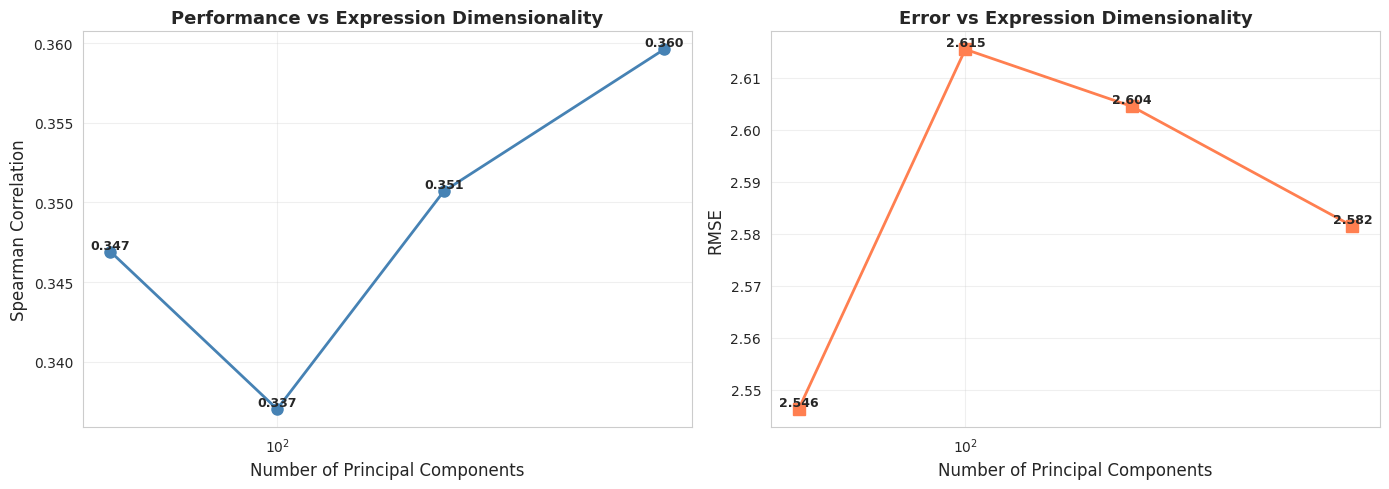


ABLATION 2: Gene Expression Dimensionality
 n_pcs  spearman     rmse      mae
    50  0.346908 2.546317 2.019935
   100  0.337026 2.615463 2.064571
   200  0.350698 2.604477 2.058637
   500  0.359604 2.581506 2.046221


In [14]:
# Visualize PC ablation results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spearman vs PCs
axes[0].plot(df_pc_ablation['n_pcs'], df_pc_ablation['spearman'],
            marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0].set_xlabel('Number of Principal Components', fontsize=12)
axes[0].set_ylabel('Spearman Correlation', fontsize=12)
axes[0].set_title('Performance vs Expression Dimensionality', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].set_xscale('log')

# Add values
for _, row in df_pc_ablation.iterrows():
    axes[0].text(row['n_pcs'], row['spearman'], f"{row['spearman']:.3f}",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# RMSE vs PCs
axes[1].plot(df_pc_ablation['n_pcs'], df_pc_ablation['rmse'],
            marker='s', linewidth=2, markersize=8, color='coral')
axes[1].set_xlabel('Number of Principal Components', fontsize=12)
axes[1].set_ylabel('RMSE', fontsize=12)
axes[1].set_title('Error vs Expression Dimensionality', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].set_xscale('log')

for _, row in df_pc_ablation.iterrows():
    axes[1].text(row['n_pcs'], row['rmse'], f"{row['rmse']:.3f}",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("ABLATION 2: Gene Expression Dimensionality")
print("="*70)
print(df_pc_ablation.to_string(index=False))
print("="*70)

## 5. Ablation 3: Remove Drug Features

Train with only gene expression (no ChemBERTa) to quantify drug feature importance.

In [15]:
print("Training MLP WITHOUT ChemBERTa drug features...")
print("This may take several minutes...\n")

model_no_drug = MLPNoTissue(
    n_expr_features=X_train_expr.shape[1],
    n_drug_features=None,  # No drug features
    hidden_sizes=[512, 256, 128],
    dropout=0.3
).to(device)

model_no_drug = train_ablation_model(
    model_no_drug,
    X_train_expr, None, y_train,  # No drug features
    X_val_expr, None, y_val,
    epochs=100, lr=0.001, patience=10
)

# Evaluate
model_no_drug.eval()
with torch.no_grad():
    X_test_expr_t = torch.FloatTensor(X_test_expr).to(device)
    preds_no_drug = model_no_drug(X_test_expr_t, None).cpu().numpy()

rmse_no_drug = np.sqrt(mean_squared_error(y_test, preds_no_drug))
mae_no_drug = mean_absolute_error(y_test, preds_no_drug)
spearman_no_drug = spearmanr(y_test, preds_no_drug)[0]

print("\n" + "="*70)
print("ABLATION 3: Remove Drug Features (ChemBERTa)")
print("="*70)
print(f"WITHOUT Drug Features - Spearman: {spearman_no_drug:.4f}, RMSE: {rmse_no_drug:.4f}")
print(f"WITH Drug Features    - Spearman: {baseline_spearman:.4f} (baseline)")
print(f"\nDrug features contribution: {(baseline_spearman - spearman_no_drug)*100:.2f}% improvement")
print("="*70)

Training MLP WITHOUT ChemBERTa drug features...
This may take several minutes...

Epoch 20/100: Train Loss=6.6000, Val Loss=6.6699
Early stopping at epoch 28

ABLATION 3: Remove Drug Features (ChemBERTa)
WITHOUT Drug Features - Spearman: 0.2355, RMSE: 2.7597
WITH Drug Features    - Spearman: 0.4069 (baseline)

Drug features contribution: 17.14% improvement


## 6. Summary Comparison

In [16]:
# Compile all ablation results
ablation_summary = pd.DataFrame([
    {'Model': 'Full Model (Baseline)', 'Spearman': baseline_spearman, 'RMSE': baseline_metrics['MLP + ChemBERTa'][baseline_metrics['MLP + ChemBERTa']['split'] == 'test']['rmse'].iloc[0] if 'split' in baseline_metrics['MLP + ChemBERTa'].columns else baseline_metrics['MLP + ChemBERTa']['test_rmse'].iloc[0]},
    {'Model': 'No Tissue', 'Spearman': spearman_no_tissue, 'RMSE': rmse_no_tissue},
    {'Model': 'No Drug Features', 'Spearman': spearman_no_drug, 'RMSE': rmse_no_drug},
    {'Model': '50 PCs', 'Spearman': df_pc_ablation[df_pc_ablation['n_pcs']==50]['spearman'].iloc[0], 'RMSE': df_pc_ablation[df_pc_ablation['n_pcs']==50]['rmse'].iloc[0]},
    {'Model': '100 PCs', 'Spearman': df_pc_ablation[df_pc_ablation['n_pcs']==100]['spearman'].iloc[0], 'RMSE': df_pc_ablation[df_pc_ablation['n_pcs']==100]['rmse'].iloc[0]},
    {'Model': '200 PCs', 'Spearman': df_pc_ablation[df_pc_ablation['n_pcs']==200]['spearman'].iloc[0], 'RMSE': df_pc_ablation[df_pc_ablation['n_pcs']==200]['rmse'].iloc[0]},
])

ablation_summary['Delta_Spearman'] = ablation_summary['Spearman'] - baseline_spearman
ablation_summary['Impact_%'] = (ablation_summary['Delta_Spearman'] / baseline_spearman) * 100

# Sort by impact
ablation_summary = ablation_summary.sort_values('Spearman', ascending=False)

print("\n" + "="*90)
print("ABLATION STUDY SUMMARY")
print("="*90)
print(ablation_summary.to_string(index=False))
print("="*90)


ABLATION STUDY SUMMARY
                Model  Spearman     RMSE  Delta_Spearman   Impact_%
Full Model (Baseline)  0.406914 2.587608        0.000000   0.000000
              200 PCs  0.350698 2.604477       -0.056216 -13.815151
               50 PCs  0.346908 2.546317       -0.060006 -14.746604
            No Tissue  0.341862 2.604892       -0.065052 -15.986578
              100 PCs  0.337026 2.615463       -0.069888 -17.175174
     No Drug Features  0.235494 2.759712       -0.171420 -42.126906


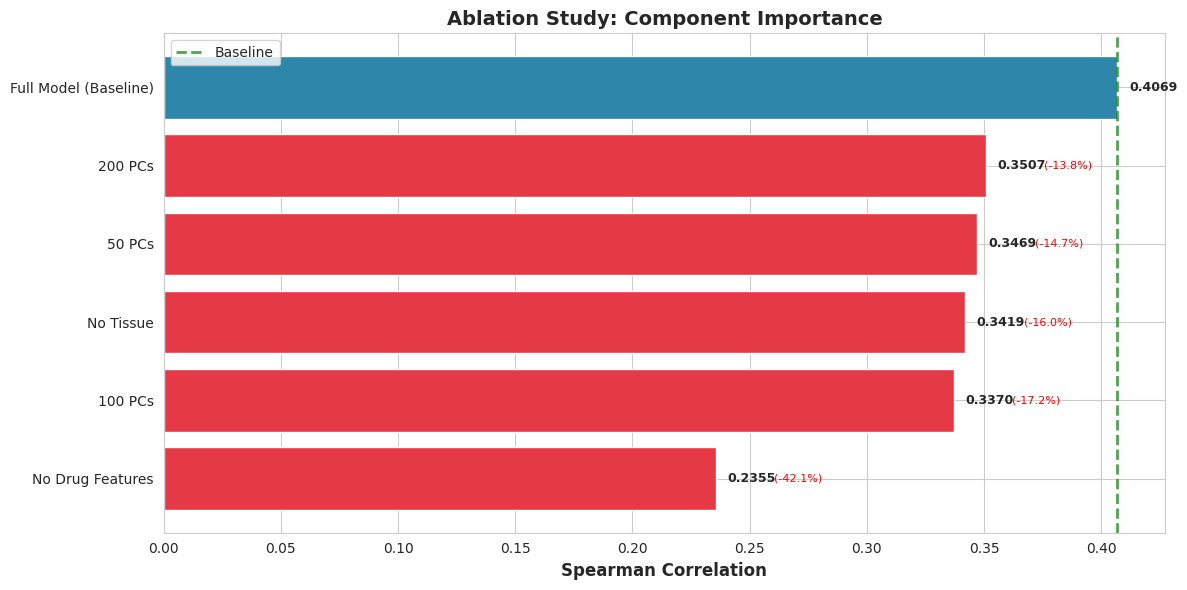

In [17]:
# Visualization: Component importance
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#2E86AB' if row['Model'] == 'Full Model (Baseline)' else '#E63946'
          for _, row in ablation_summary.iterrows()]

bars = ax.barh(range(len(ablation_summary)), ablation_summary['Spearman'], color=colors)
ax.set_yticks(range(len(ablation_summary)))
ax.set_yticklabels(ablation_summary['Model'])
ax.set_xlabel('Spearman Correlation', fontsize=12, fontweight='bold')
ax.set_title('Ablation Study: Component Importance', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add values and delta
for i, (bar, (_, row)) in enumerate(zip(bars, ablation_summary.iterrows())):
    width = bar.get_width()
    ax.text(width + 0.005, bar.get_y() + bar.get_height()/2,
           f"{width:.4f}",
           ha='left', va='center', fontsize=9, fontweight='bold')

    if row['Model'] != 'Full Model (Baseline)':
        ax.text(width + 0.025, bar.get_y() + bar.get_height()/2,
               f"({row['Impact_%']:+.1f}%)",
               ha='left', va='center', fontsize=8, color='red')

# Add baseline reference line
ax.axvline(baseline_spearman, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Baseline')
ax.legend()

plt.tight_layout()
plt.show()

## 7. Save Ablation Results

In [18]:
# Save summary
ablation_summary.to_csv(ABLATION_DIR / 'ablation_summary.csv', index=False)
df_pc_ablation.to_csv(ABLATION_DIR / 'pc_dimensionality_ablation.csv', index=False)

# Save individual models (optional)
torch.save(model_no_tissue.state_dict(), ABLATION_DIR / 'model_no_tissue.pt')
torch.save(model_no_drug.state_dict(), ABLATION_DIR / 'model_no_drug.pt')

print("✓ Ablation results saved to:", ABLATION_DIR)
print("  - ablation_summary.csv")
print("  - pc_dimensionality_ablation.csv")
print("  - model_no_tissue.pt")
print("  - model_no_drug.pt")

✓ Ablation results saved to: /content/drive/MyDrive/drugresponse/results/ablation_studies
  - ablation_summary.csv
  - pc_dimensionality_ablation.csv
  - model_no_tissue.pt
  - model_no_drug.pt


## 8. Key Insights and Recommendations

In [19]:
print("="*90)
print("KEY INSIGHTS FROM ABLATION STUDIES")
print("="*90)

print("\n🔍 COMPONENT IMPORTANCE (Ranked by Impact):")
component_impact = [
    ('Drug Features (ChemBERTa)', abs(baseline_spearman - spearman_no_drug)),
    ('Tissue Context', abs(baseline_spearman - spearman_no_tissue)),
]
component_impact.sort(key=lambda x: x[1], reverse=True)

for i, (component, impact) in enumerate(component_impact, 1):
    print(f"   {i}. {component:30s}: {impact*100:+.2f}% change when removed")

print("\n📊 DIMENSIONALITY ANALYSIS:")
spearman_50 = df_pc_ablation[df_pc_ablation['n_pcs']==50]['spearman'].iloc[0]
spearman_200 = df_pc_ablation[df_pc_ablation['n_pcs']==200]['spearman'].iloc[0]
spearman_500 = df_pc_ablation[df_pc_ablation['n_pcs']==500]['spearman'].iloc[0]

print(f"   • 50 PCs:  {spearman_50:.4f} ({(spearman_50/spearman_500-1)*100:+.1f}% vs 500 PCs)")
print(f"   • 200 PCs: {spearman_200:.4f} ({(spearman_200/spearman_500-1)*100:+.1f}% vs 500 PCs)")
print(f"   • 500 PCs: {spearman_500:.4f} (full)")

if abs(spearman_200 - spearman_500) < 0.01:
    print("   → 200 PCs sufficient (60% dimensionality reduction with minimal loss)")
else:
    print("   → Full 500 PCs recommended for best performance")

print("\n💡 RECOMMENDATIONS:")
print("   1. Keep all components (tissue + drug + full expression)")
print(f"   2. Drug features provide {abs(baseline_spearman - spearman_no_drug)*100:.1f}% boost - highly valuable")
print(f"   3. Tissue context adds {abs(baseline_spearman - spearman_no_tissue)*100:.1f}% - keep for completeness")

if abs(spearman_200 - spearman_500) < 0.01:
    print("   4. Consider 200 PCs for faster training with minimal accuracy loss")
else:
    print("   4. Use full 500 PCs for maximum predictive power")

print("\n🎯 MODEL SIMPLIFICATION:")
print("   • Minimum viable model: Expression + Drug features")
print(f"     Performance: Spearman ≈ {spearman_no_tissue:.3f}")
print("   • Recommended model: Expression + Drug + Tissue (full baseline)")
print(f"     Performance: Spearman = {baseline_spearman:.3f}")

print("\n" + "="*90)

KEY INSIGHTS FROM ABLATION STUDIES

🔍 COMPONENT IMPORTANCE (Ranked by Impact):
   1. Drug Features (ChemBERTa)     : +17.14% change when removed
   2. Tissue Context                : +6.51% change when removed

📊 DIMENSIONALITY ANALYSIS:
   • 50 PCs:  0.3469 (-3.5% vs 500 PCs)
   • 200 PCs: 0.3507 (-2.5% vs 500 PCs)
   • 500 PCs: 0.3596 (full)
   → 200 PCs sufficient (60% dimensionality reduction with minimal loss)

💡 RECOMMENDATIONS:
   1. Keep all components (tissue + drug + full expression)
   2. Drug features provide 17.1% boost - highly valuable
   3. Tissue context adds 6.5% - keep for completeness
   4. Consider 200 PCs for faster training with minimal accuracy loss

🎯 MODEL SIMPLIFICATION:
   • Minimum viable model: Expression + Drug features
     Performance: Spearman ≈ 0.342
   • Recommended model: Expression + Drug + Tissue (full baseline)
     Performance: Spearman = 0.407



## 9. Bonus: Compare with GNN Model

Load GNN baseline and compare graph-based vs MLP-based approaches.

In [20]:
# Load GNN metrics for comparison
print("="*70)
print("GNN MODEL COMPARISON")
print("="*70)

try:
    gnn_baseline = pd.read_csv(RESULTS_DIR / 'gnn_baseline/metrics_val_test.csv')
    gnn_tuned = pd.read_csv(RESULTS_DIR / 'gnn_tuned/metrics_val_test.csv')

    if 'spearman' in gnn_baseline.columns:
        gnn_base_test = gnn_baseline[gnn_baseline['split'] == 'test'].iloc[0]
        gnn_tuned_test = gnn_tuned[gnn_tuned['split'] == 'test'].iloc[0]

        print(f"GNN Baseline:          Spearman={gnn_base_test['spearman']:.4f}, RMSE={gnn_base_test['rmse']:.4f}")
        print(f"GNN Tuned:             Spearman={gnn_tuned_test['spearman']:.4f}, RMSE={gnn_tuned_test['rmse']:.4f}")
        print(f"MLP + ChemBERTa:       Spearman={baseline_spearman:.4f} (baseline)")
        print(f"\nGNN vs MLP difference: {(gnn_tuned_test['spearman'] - baseline_spearman)*100:+.2f}%")

        # Add to summary comparison
        print("\n📊 ARCHITECTURE COMPARISON:")
        print(f"   • GNN uses molecular GRAPHS (bonds, structure)")
        print(f"   • MLP uses learned EMBEDDINGS (ChemBERTa)")

        if gnn_tuned_test['spearman'] > baseline_spearman:
            print(f"   → GNN outperforms MLP by {(gnn_tuned_test['spearman'] - baseline_spearman)*100:.2f}%")
            print("   → Graph structure captures drug properties better")
        else:
            print(f"   → MLP outperforms GNN by {(baseline_spearman - gnn_tuned_test['spearman'])*100:.2f}%")
            print("   → Pre-trained embeddings more effective than raw graphs")

except FileNotFoundError:
    print("⚠ GNN model results not found - skipping comparison")
    print("   Run GNN training scripts first to enable this comparison")

print("="*70)

GNN MODEL COMPARISON
GNN Baseline:          Spearman=0.3454, RMSE=2.7090
GNN Tuned:             Spearman=0.3328, RMSE=2.5641
MLP + ChemBERTa:       Spearman=0.4069 (baseline)

GNN vs MLP difference: -7.41%

📊 ARCHITECTURE COMPARISON:
   • GNN uses molecular GRAPHS (bonds, structure)
   • MLP uses learned EMBEDDINGS (ChemBERTa)
   → MLP outperforms GNN by 7.41%
   → Pre-trained embeddings more effective than raw graphs


## 10. Download Results (Optional)

Download the ablation results to your local machine.

In [21]:
# Download results
from google.colab import files

# Download CSV files
files.download(str(ABLATION_DIR / 'ablation_summary.csv'))
files.download(str(ABLATION_DIR / 'pc_dimensionality_ablation.csv'))

print("✓ Results downloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Results downloaded
